# Car Sales Analysis

## Product & Sales Performance Analysis

In [ ]:
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [ ]:
df = pd.read_csv('car_sales.csv')

## Initial Data Inspection

In [ ]:
df.head()

,Car_id,Date,Customer Name,Gender,Annual Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price ($),Dealer_No,Body Style,Phone,Dealer_Region
0,C_CND_000001,1/2/2022,Geraldine,Male,13500,Buddy Storbeck's Diesel Service Inc,Ford,Expedition,DoubleÂ Overhead Camshaft,Auto,Black,26000,06457-3834,SUV,8264678,Middletown
1,C_CND_000002,1/2/2022,Gia,Male,1480000,C & M Motors Inc,Dodge,Durango,DoubleÂ Overhead Camshaft,Auto,Black,19000,60504-7114,SUV,6848189,Aurora
2,C_CND_000003,1/2/2022,Gianna,Male,1035000,Capitol KIA,Cadillac,Eldorado,Overhead Camshaft,Manual,Red,31500,38701-8047,Passenger,7298798,Greenville
3,C_CND_000004,1/2/2022,Giselle,Male,13500,Chrysler of Tri-Cities,Toyota,Celica,Overhead Camshaft,Manual,Pale White,14000,99301-3882,SUV,6257557,Pasco
4,C_CND_000005,1/2/2022,Grace,Male,1465000,Chrysler Plymouth,Acura,TL,DoubleÂ Overhead Camshaft,Auto,Red,24500,53546-9427,Hatchback,7081483,Janesville


In [ ]:
print("Rows:", df.shape[0])
print("Columns:", df.shape[1])

Rows: 23906
Columns: 16


In [ ]:
df.columns

Index(['Car_id', 'Date', 'Customer Name', 'Gender', 'Annual Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price ($)', 'Dealer_No ', 'Body Style', 'Phone', 'Dealer_Region'],
      dtype='object')

In [ ]:
df.dtypes

,0
Car_id,object
Date,object
Customer Name,object
Gender,object
Annual Income,int64
Dealer_Name,object
Company,object
Model,object
Engine,object
Transmission,object


In [ ]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 23906 entries, 0 to 23905
Data columns (total 16 columns):
 #   Column         Non-Null Count  Dtype 
---  ------         --------------  ----- 
 0   Car_id         23906 non-null  object
 1   Date           23906 non-null  object
 2   Customer Name  23905 non-null  object
 3   Gender         23906 non-null  object
 4   Annual Income  23906 non-null  int64 
 5   Dealer_Name    23906 non-null  object
 6   Company        23906 non-null  object
 7   Model          23906 non-null  object
 8   Engine         23906 non-null  object
 9   Transmission   23906 non-null  object
 10  Color          23906 non-null  object
 11  Price ($)      23906 non-null  int64 
 12  Dealer_No      23906 non-null  object
 13  Body Style     23906 non-null  object
 14  Phone          23906 non-null  int64 
 15  Dealer_Region  23906 non-null  object
dtypes: int64(3), object(13)
memory usage: 2.9+ MB


In [ ]:
df.isnull().sum()

,0
Car_id,0
Date,0
Customer Name,1
Gender,0
Annual Income,0
Dealer_Name,0
Company,0
Model,0
Engine,0
Transmission,0


In [ ]:
df.duplicated().sum()

np.int64(0)

In [ ]:
print("Unique Car IDs:", df['Car_id'].nunique())
print("Car ID is unique:", df['Car_id'].is_unique)

Unique Car IDs: 23906
Car ID is unique: True


In [ ]:
df[['Annual Income', 'Price ($)']].describe()

,Annual Income,Price ($)
count,2.390600e+04,23906.000000
mean,8.308403e+05,28090.247846
std,7.200064e+05,14788.687608
min,1.008000e+04,1200.000000
25%,3.860000e+05,18001.000000
50%,7.350000e+05,23000.000000
75%,1.175750e+06,34000.000000
max,1.120000e+07,85800.000000


## Data Cleaning

### Standardize Column Names

In [ ]:
df.columns = df.columns.str.strip().str.replace(' ', '_', regex=False)

df.columns

Index(['Car_id', 'Date', 'Customer_Name', 'Gender', 'Annual_Income',
       'Dealer_Name', 'Company', 'Model', 'Engine', 'Transmission', 'Color',
       'Price_($)', 'Dealer_No', 'Body_Style', 'Phone', 'Dealer_Region'],
      dtype='object')

### Convert Date to Datetime


In [ ]:
df['Date'] = pd.to_datetime(df['Date'], format='%m/%d/%Y', errors='coerce')

print("Date data type:", df['Date'].dtype)
print("Invalid dates:", df['Date'].isna().sum())
print("Date range:", df['Date'].min(), "to", df['Date'].max())

Date data type: datetime64[ns]
Invalid dates: 0
Date range: 2022-01-02 00:00:00 to 2023-12-31 00:00:00


### Standardize Text Fields

In [ ]:
text_columns = df.select_dtypes(include='object').columns

for col in text_columns:
    df[col] = df[col].str.strip()
    df[col] = df[col].replace('', np.nan)

### Clean Engine Values

In [ ]:
df['Engine'] = (df['Engine'].str.replace('Â', '', regex=False).str.replace('\xa0', ' ', regex=False)
                            .str.replace(r'\s+', ' ', regex=True).str.strip())

df['Engine'].value_counts()

,count
Engine,
Double Overhead Camshaft,12571
Overhead Camshaft,11335


### Handle Missing Customer Names

In [ ]:
print("Missing Customer_Name:", df['Customer_Name'].isna().sum())

Missing Customer_Name: 1


### Handle Missing Models

In [ ]:
print("Missing Model before treatment:", df['Model'].isna().sum())
display(df[df['Model'].isna()].head())

Missing Model before treatment: 0


,Car_id,Date,Customer_Name,Gender,Annual_Income,Dealer_Name,Company,Model,Engine,Transmission,Color,Price_($),Dealer_No,Body_Style,Phone,Dealer_Region


In [ ]:
df['Model'] = df['Model'].fillna('Unknown')        # Label unavailable model information explicitly

print("Missing Model after treatment:", df['Model'].isna().sum())
print("Unknown Model records:", (df['Model'] == 'Unknown').sum())

Missing Model after treatment: 0
Unknown Model records: 0


## Numeric Data Quality Assessment

### Validate Numerical Values

In [ ]:
print("Annual Income <= 0:", (df['Annual_Income'] <= 0).sum())
print("Price <= 0:", (df['Price_($)'] <= 0).sum())

Annual Income <= 0: 0
Price <= 0: 0


### Numerical Distribution

In [ ]:
print("Annual Income Summary:")
display(df['Annual_Income'].describe())

print("Price Summary:")
display(df['Price_($)'].describe())

Annual Income Summary:


,Annual_Income
count,2.390600e+04
mean,8.308403e+05
std,7.200064e+05
min,1.008000e+04
25%,3.860000e+05
50%,7.350000e+05
75%,1.175750e+06
max,1.120000e+07


Price Summary:


,Price_($)
count,23906.000000
mean,28090.247846
std,14788.687608
min,1200.000000
25%,18001.000000
50%,23000.000000
75%,34000.000000
max,85800.000000


### Detect Statistical Outliers Using IQR

In [ ]:
def get_iqr_bounds(series):
    q1 = series.quantile(0.25)
    q3 = series.quantile(0.75)
    iqr = q3 - q1

    lower_bound = q1 - 1.5 * iqr
    upper_bound = q3 + 1.5 * iqr

    return lower_bound, upper_bound

In [ ]:
income_lower, income_upper = get_iqr_bounds(df['Annual_Income'])
price_lower, price_upper = get_iqr_bounds(df['Price_($)'])

income_outliers = df[(df['Annual_Income'] < income_lower) | (df['Annual_Income'] > income_upper)]

price_outliers = df[(df['Price_($)'] < price_lower) | (df['Price_($)'] > price_upper)]

outlier_summary = pd.DataFrame({
    'Variable': ['Annual_Income', 'Price_($)'],
    'Outlier_Count': [len(income_outliers), len(price_outliers)],
    'Outlier_%': [
        len(income_outliers) / len(df) * 100,
        len(price_outliers) / len(df) * 100
    ]
})

outlier_summary

,Variable,Outlier_Count,Outlier_%
0,Annual_Income,816,3.413369
1,Price_($),1449,6.061240


### Outlier Treatment Decision

In [ ]:
print("Highest Annual Income values:")
display(
    df[['Car_id', 'Annual_Income']]
    .sort_values('Annual_Income', ascending=False)
    .head(10)
)

print("Highest Car Price values:")
display(df[['Car_id', 'Price_($)']].sort_values('Price_($)', ascending=False).head(10))

Highest Annual Income values:


,Car_id,Annual_Income
14026,C_CND_014027,11200000
15675,C_CND_015676,8000000
6150,C_CND_006151,7650000
9996,C_CND_009997,6800000
22407,C_CND_022408,6600000
11607,C_CND_011608,6500000
7657,C_CND_007658,6460000
8817,C_CND_008818,6400000
14183,C_CND_014184,6400000
4755,C_CND_004756,6240000


Highest Car Price values:


,Car_id,Price_($)
7068,C_CND_007069,85800
17129,C_CND_017130,85601
358,C_CND_000359,85600
13605,C_CND_013606,85600
9228,C_CND_009229,85500
11330,C_CND_011331,85500
17947,C_CND_017948,85400
2661,C_CND_002662,85301
11428,C_CND_011429,85300
6530,C_CND_006531,85250


## Final Cleaning Validation


In [ ]:
print("Rows:", len(df))
print("Columns:", len(df.columns))
print("Duplicate rows:", df.duplicated().sum())
print("Unique Car IDs:", df['Car_id'].nunique())
print("Car ID is unique:", df['Car_id'].is_unique)

print("\nMissing values:")
print(df.isna().sum())

print("\nInvalid Annual Income:", (df['Annual_Income'] <= 0).sum())
print("Invalid Price:", (df['Price_($)'] <= 0).sum())

print("\nDate range:")
print(df['Date'].min(), "to", df['Date'].max())

Rows: 23906
Columns: 16
Duplicate rows: 0
Unique Car IDs: 23906
Car ID is unique: True

Missing values:
Car_id           0
Date             0
Customer_Name    1
Gender           0
Annual_Income    0
Dealer_Name      0
Company          0
Model            0
Engine           0
Transmission     0
Color            0
Price_($)        0
Dealer_No        0
Body_Style       0
Phone            0
Dealer_Region    0
dtype: int64

Invalid Annual Income: 0
Invalid Price: 0

Date range:
2022-01-02 00:00:00 to 2023-12-31 00:00:00


## Date Features


In [ ]:
df['Year'] = df['Date'].dt.year
df['Quarter'] = df['Date'].dt.quarter
df['Month'] = df['Date'].dt.month

df[['Date', 'Year', 'Quarter', 'Month']].head()

,Date,Year,Quarter,Month
0,2022-01-02,2022,1,1
1,2022-01-02,2022,1,1
2,2022-01-02,2022,1,1
3,2022-01-02,2022,1,1
4,2022-01-02,2022,1,1


In [ ]:
print("Years:", sorted(df['Year'].dropna().unique()))
print("Quarters:", sorted(df['Quarter'].dropna().unique()))
print("Months:", sorted(df['Month'].dropna().unique()))

Years: [np.int32(2022), np.int32(2023)]
Quarters: [np.int32(1), np.int32(2), np.int32(3), np.int32(4)]
Months: [np.int32(1), np.int32(2), np.int32(3), np.int32(4), np.int32(5), np.int32(6), np.int32(7), np.int32(8), np.int32(9), np.int32(10), np.int32(11), np.int32(12)]


## KPI Foundation

In [ ]:
total_sales = df['Price_($)'].sum()
cars_sold = df['Car_id'].nunique()
average_price = df['Price_($)'].mean()
median_price = df['Price_($)'].median()
minimum_price = df['Price_($)'].min()
maximum_price = df['Price_($)'].max()

print(f"Total Sales: ${total_sales:,.2f}")
print(f"Cars Sold: {cars_sold:,}")
print(f"Average Selling Price: ${average_price:,.2f}")
print(f"Median Selling Price: ${median_price:,.2f}")
print(f"Minimum Car Price: ${minimum_price:,.2f}")
print(f"Maximum Car Price: ${maximum_price:,.2f}")

Total Sales: $671,525,465.00
Cars Sold: 23,906
Average Selling Price: $28,090.25
Median Selling Price: $23,000.00
Minimum Car Price: $1,200.00
Maximum Car Price: $85,800.00


## Sales Performance Over Time

In [ ]:
annual_sales = (df.groupby('Year').agg(Total_Sales=('Price_($)', 'sum'), Cars_Sold=('Car_id', 'nunique'),
                                       Average_Price=('Price_($)', 'mean')).reset_index())

annual_sales['Sales_Growth_%'] = (annual_sales['Total_Sales'].pct_change() * 100)

annual_sales

,Year,Total_Sales,Cars_Sold,Average_Price,Sales_Growth_%
0,2022,300340345,10645,28214.217473,NaN
1,2023,371185120,13261,27990.733730,23.588165


### Year-over-Year Interpretation

In [ ]:
monthly_sales = (df.groupby(df['Date'].dt.to_period('M'))
              .agg(Total_Sales=('Price_($)', 'sum'),Cars_Sold=('Car_id', 'nunique')).reset_index())

monthly_sales['Date'] = monthly_sales['Date'].dt.to_timestamp()

monthly_sales

,Date,Total_Sales,Cars_Sold
0,2022-01-01,8931920,315
1,2022-02-01,8795365,320
2,2022-03-01,19502059,705
3,2022-04-01,22748867,800
4,2022-05-01,20608086,750
5,2022-06-01,19604211,690
6,2022-07-01,19935002,700
7,2022-08-01,23631362,810
8,2022-09-01,42218216,1475
9,2022-10-01,23991509,835


In [ ]:
best_month = monthly_sales.loc[monthly_sales['Total_Sales'].idxmax()]
worst_month = monthly_sales.loc[monthly_sales['Total_Sales'].idxmin()]

print("Best Month:")
display(best_month.to_frame().T)

print("Worst Month:")
display(worst_month.to_frame().T)

Best Month:


,Date,Total_Sales,Cars_Sold
23,2023-12-01 00:00:00,54281601,1921


Worst Month:


,Date,Total_Sales,Cars_Sold
1,2022-02-01 00:00:00,8795365,320


In [ ]:
monthly_year_comparison = (df.groupby(['Year', 'Month'])
      .agg(Total_Sales=('Price_($)', 'sum'), Cars_Sold=('Car_id', 'nunique'), Average_Price=('Price_($)', 'mean')).reset_index())

monthly_sales_pivot = (monthly_year_comparison.pivot(index='Month', columns='Year', values='Total_Sales'))

monthly_sales_pivot

Year,2022,2023
Month,,
1,8931920,12764298
2,8795365,11848580
3,19502059,22203814
4,22748867,24115567
5,20608086,32613157
6,19604211,28901691
7,19935002,28243030
8,23631362,25162276
9,42218216,51416962


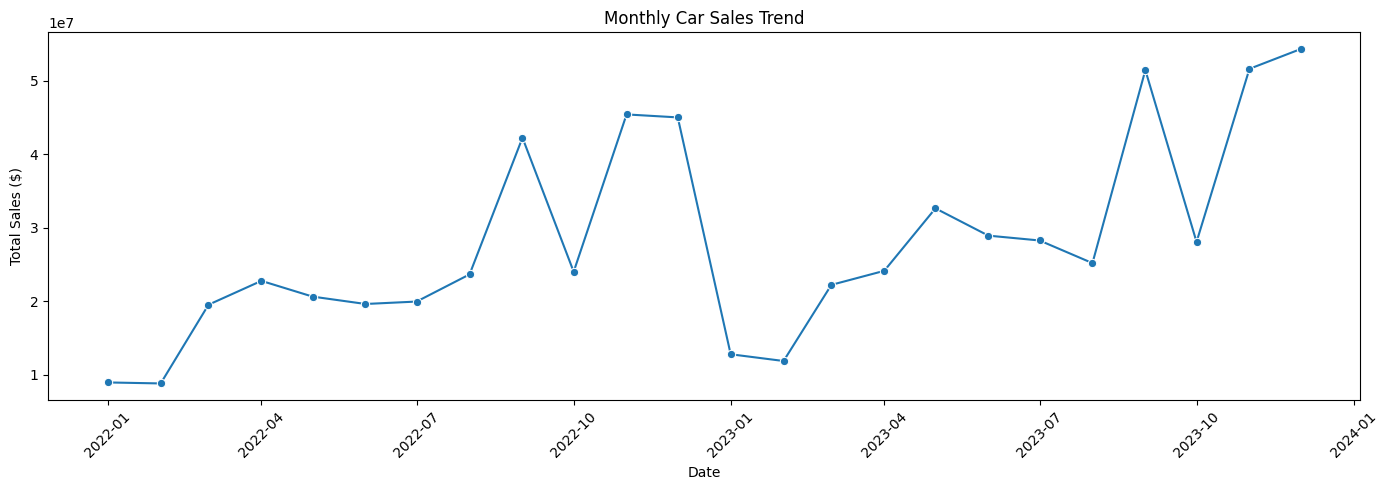

In [ ]:
plt.figure(figsize=(14, 5))

sns.lineplot(data=monthly_sales, x='Date', y='Total_Sales', marker='o')

plt.title('Monthly Car Sales Trend')
plt.xlabel('Date')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=45)
plt.tight_layout()
plt.show()

## Company Performance

In [ ]:
company_performance = (df.groupby('Company').agg(Total_Sales=('Price_($)', 'sum'),
                                                 Cars_Sold=('Car_id', 'nunique'), Average_Price=('Price_($)', 'mean')).reset_index())

company_performance['Sales_Contribution_%'] = (company_performance['Total_Sales'] / company_performance['Total_Sales'].sum() * 100)

company_performance = company_performance.sort_values('Total_Sales', ascending=False)

company_performance.head(10)

,Company,Total_Sales,Cars_Sold,Average_Price,Sales_Contribution_%
5,Chevrolet,47655265,1819,26198.606377,7.096569
8,Ford,47231583,1614,29263.682156,7.033476
7,Dodge,44124996,1671,26406.341113,6.570860
20,Oldsmobile,35434512,1111,31894.250225,5.276719
16,Mercedes-B,34624123,1285,26944.842802,5.156040
28,Volkswagen,34082881,1333,25568.552888,5.075441
18,Mitsubishi,34062466,1277,26673.818324,5.072401
27,Toyota,32759564,1110,29513.120721,4.878380
6,Chrysler,29141873,1120,26019.529464,4.339653
14,Lexus,27287703,802,34024.567332,4.063540


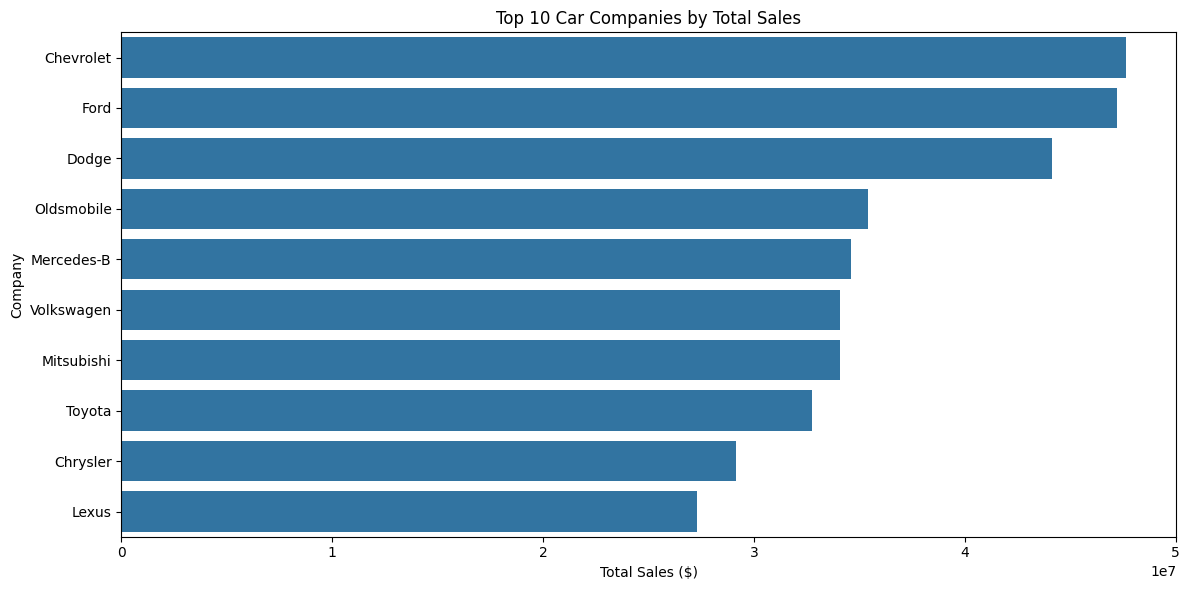

In [ ]:
top_10_companies = company_performance.head(10)

plt.figure(figsize=(12, 6))

sns.barplot(data=top_10_companies, x='Total_Sales', y='Company')

plt.title('Top 10 Car Companies by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Company')
plt.tight_layout()
plt.show()

In [ ]:
top_price_companies = (company_performance.sort_values('Average_Price', ascending=False).head(10))

top_price_companies[['Company', 'Average_Price', 'Cars_Sold', 'Total_Sales']]

,Company,Average_Price,Cars_Sold,Total_Sales
4,Cadillac,40972.093558,652,26713805
24,Saab,36516.338095,210,7668431
14,Lexus,34024.567332,802,27287703
3,Buick,33634.362187,439,14765485
20,Oldsmobile,31894.250225,1111,35434512
15,Lincoln,31407.036585,492,15452262
25,Saturn,31092.609215,586,18220269
27,Toyota,29513.120721,1110,32759564
21,Plymouth,29404.980551,617,18142873
22,Pontiac,29358.300251,796,23369207


### Company-Level Interpretation

## Model Performance

In [ ]:
model_performance = (df.groupby(['Company', 'Model'])
      .agg(Total_Sales=('Price_($)', 'sum'), Cars_Sold=('Car_id', 'nunique'), Average_Price=('Price_($)', 'mean'))
      .reset_index()
      .sort_values('Total_Sales', ascending=False))

model_performance.head(15)

,Company,Model,Total_Sales,Cars_Sold,Average_Price
72,Lexus,LS400,14263424,354,40292.158192
147,Volkswagen,Jetta,12287736,382,32166.848168
112,Oldsmobile,Silhouette,12271849,411,29858.513382
99,Mitsubishi,Montero Sport,11472231,302,37987.519868
40,Dodge,Ram Pickup,10655391,383,27820.864230
15,Cadillac,Eldorado,9725407,232,41919.857759
8,BMW,528i,9577927,324,29561.503086
26,Chevrolet,Prizm,9386606,411,22838.457421
94,Mitsubishi,Diamante,9308151,418,22268.303828
30,Chrysler,LHS,9097717,330,27568.839394


In [ ]:
top_10_models = model_performance.head(10)

top_10_models

,Company,Model,Total_Sales,Cars_Sold,Average_Price
72,Lexus,LS400,14263424,354,40292.158192
147,Volkswagen,Jetta,12287736,382,32166.848168
112,Oldsmobile,Silhouette,12271849,411,29858.513382
99,Mitsubishi,Montero Sport,11472231,302,37987.519868
40,Dodge,Ram Pickup,10655391,383,27820.864230
15,Cadillac,Eldorado,9725407,232,41919.857759
8,BMW,528i,9577927,324,29561.503086
26,Chevrolet,Prizm,9386606,411,22838.457421
94,Mitsubishi,Diamante,9308151,418,22268.303828
30,Chrysler,LHS,9097717,330,27568.839394


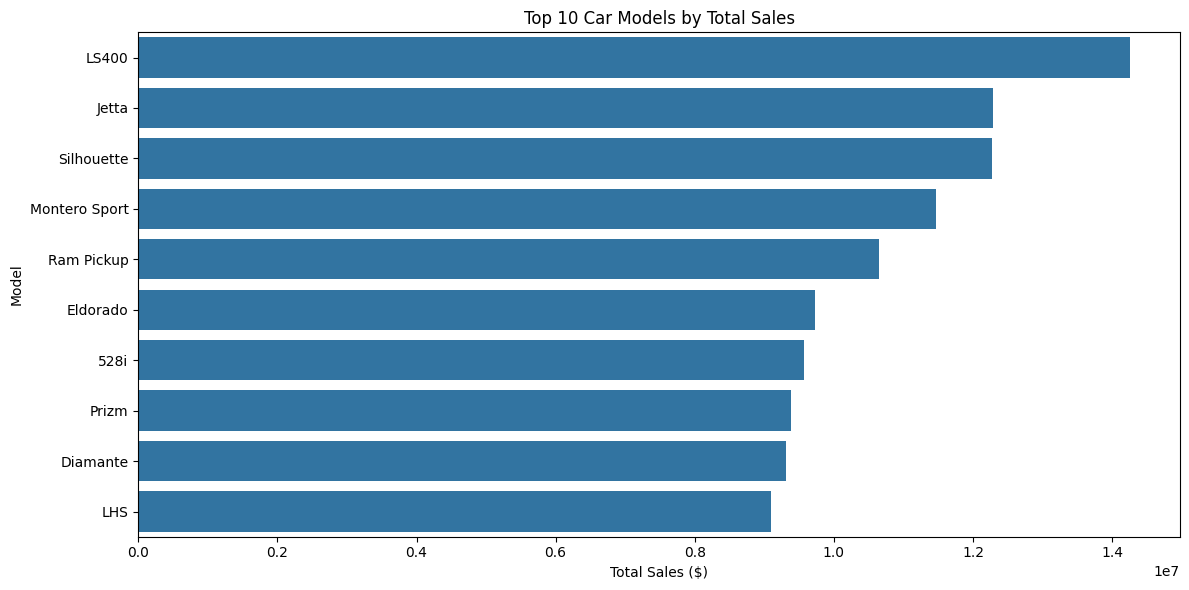

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(data=top_10_models, x='Total_Sales', y='Model')

plt.title('Top 10 Car Models by Total Sales')
plt.xlabel('Total Sales ($)')
plt.ylabel('Model')
plt.tight_layout()
plt.show()

### Model-Level Interpretation

## Dealer & Regional Performance


In [ ]:
dealer_performance = (df.groupby('Dealer_Name')
      .agg(Total_Sales=('Price_($)', 'sum'), Cars_Sold=('Car_id', 'nunique'),Average_Price=('Price_($)', 'mean'))
      .reset_index()
      .sort_values('Total_Sales', ascending=False)
)

dealer_performance.head(10)

,Dealer_Name,Total_Sales,Cars_Sold,Average_Price
19,Rabun Used Car Sales,37456655,1313,28527.536177
18,Progressive Shippers Cooperative Association No,36751460,1318,27884.264036
27,U-Haul CO,35876089,1247,28769.919006
20,Race Car Help,35288706,1253,28163.372706
22,Saab-Belle Dodge,35265865,1251,28190.139888
23,Scrivener Performance Engineering,35258525,1246,28297.371589
24,Star Enterprises Inc,35113206,1249,28113.055244
26,Tri-State Mack Inc,35091357,1249,28095.562050
25,Suburban Ford,34943473,1243,28112.206758
21,Ryder Truck Rental and Leasing,34837906,1248,27914.988782


In [ ]:
region_performance = (df.groupby('Dealer_Region')
      .agg(Total_Sales=('Price_($)', 'sum'), Cars_Sold=('Car_id', 'nunique'), Average_Price=('Price_($)', 'mean'))
      .reset_index())

region_performance['Sales_Contribution_%'] = (region_performance['Total_Sales'] / region_performance['Total_Sales'].sum() * 100)

region_performance = region_performance.sort_values('Total_Sales', ascending=False)

region_performance

,Dealer_Region,Total_Sales,Cars_Sold,Average_Price,Sales_Contribution_%
1,Austin,117192531,4135,28341.603628,17.451688
3,Janesville,106351234,3821,27833.350955,15.837260
6,Scottsdale,95969374,3433,27954.958928,14.291249
0,Aurora,88687382,3130,28334.626837,13.206853
2,Greenville,88149602,3128,28180.819054,13.126770
5,Pasco,88040714,3131,28119.039923,13.110555
4,Middletown,87134628,3128,27856.338875,12.975625


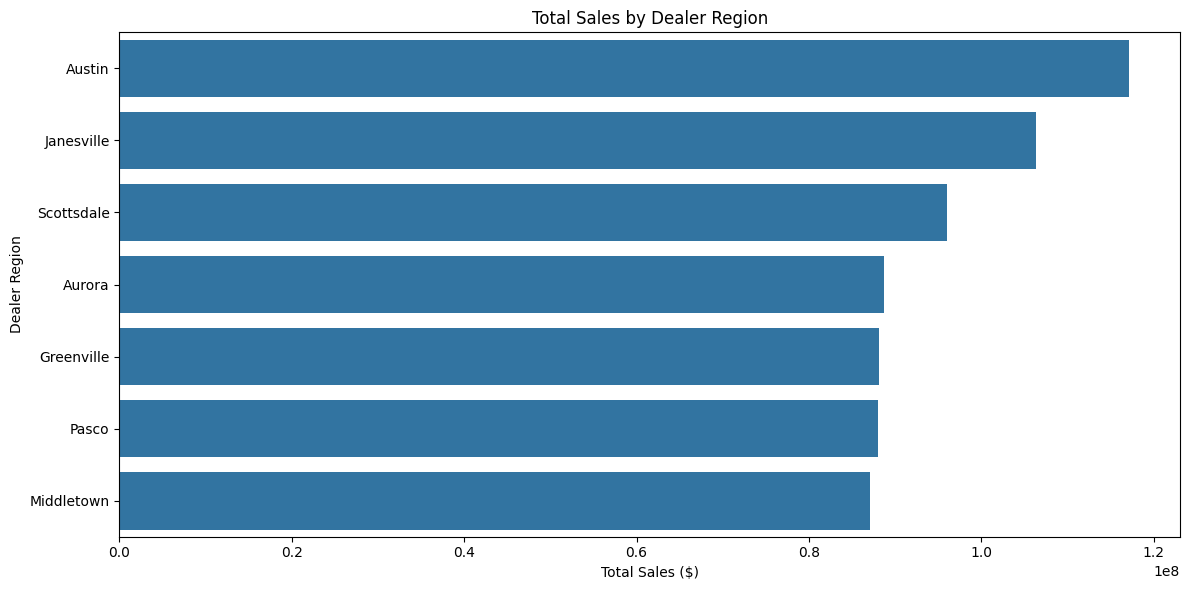

In [ ]:
plt.figure(figsize=(12, 6))

sns.barplot(data=region_performance, x='Total_Sales', y='Dealer_Region')

plt.title('Total Sales by Dealer Region')
plt.xlabel('Total Sales ($)')
plt.ylabel('Dealer Region')
plt.tight_layout()
plt.show()

### Regional Interpretation


## Vehicle Characteristics

In [ ]:
body_style_performance = (df.groupby('Body_Style')
      .agg(Total_Sales=('Price_($)', 'sum'), Cars_Sold=('Car_id', 'nunique'), Average_Price=('Price_($)', 'mean'))
      .reset_index())

body_style_performance['Sales_Contribution_%'] = (body_style_performance['Total_Sales'] / body_style_performance['Total_Sales'].sum() * 100)

body_style_performance = body_style_performance.sort_values('Total_Sales', ascending=False)

body_style_performance

,Body_Style,Total_Sales,Cars_Sold,Average_Price,Sales_Contribution_%
3,SUV,170617149,6374,26767.673204,25.407398
1,Hatchback,166234474,6128,27127.035574,24.754754
4,Sedan,133889619,4488,29832.802807,19.938130
2,Passenger,114176315,3945,28942.031686,17.002529
0,Hardtop,86607908,2971,29151.096600,12.897189


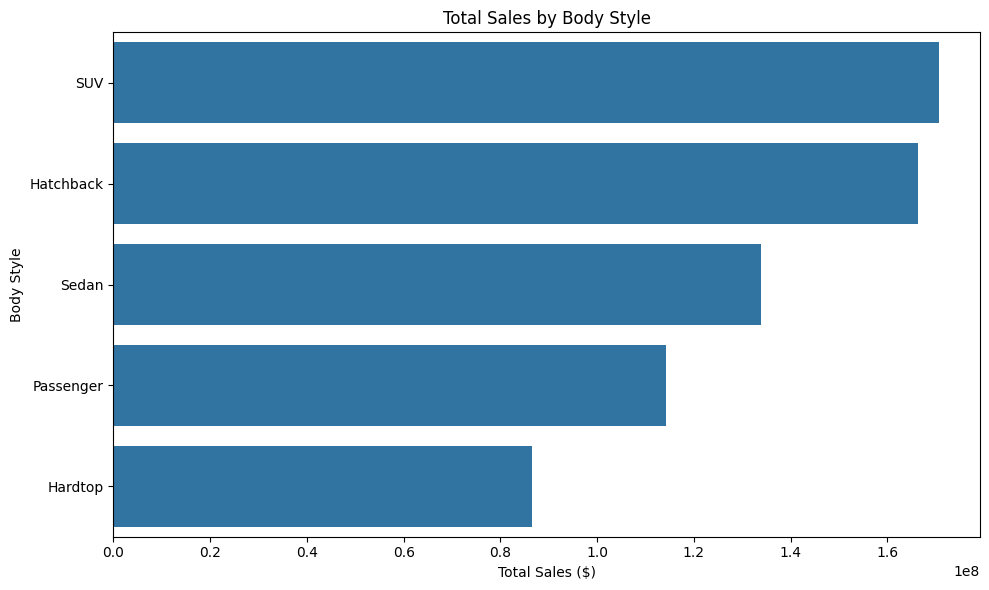

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(data=body_style_performance, x='Total_Sales', y='Body_Style')

plt.title('Total Sales by Body Style')
plt.xlabel('Total Sales ($)')
plt.ylabel('Body Style')
plt.tight_layout()
plt.show()

In [1]:
transmission_performance = (df.groupby('Transmission')
      .agg(Total_Sales=('Price_($)', 'sum'), Cars_Sold=('Car_id', 'nunique'), Average_Price=('Price_($)', 'mean'))
      .reset_index()
      .sort_values('Total_Sales', ascending=False))

transmission_performance['Sales_Contribution_%'] = (transmission_performance['Total_Sales'] / transmission_performance['Total_Sales'].sum() * 100)

transmission_performance

NameError: name 'df' is not defined

In [ ]:
engine_transmission = pd.crosstab(df['Engine'], df['Transmission'])

engine_transmission

Transmission,Auto,Manual
Engine,,
Double Overhead Camshaft,12571,0
Overhead Camshaft,0,11335


### Vehicle Characteristic Interpretation

## Pricing Analysis

In [ ]:
price_bins = [0, 10000, 25000, 50000, 100000]

price_labels = ['Under $10K', '$10K–$25K', '$25K–$50K', '$50K–$100K']

df['Price_Segment'] = pd.cut(df['Price_($)'], bins=price_bins, labels=price_labels, include_lowest=True)

In [ ]:
price_segment_performance = (df.groupby('Price_Segment', observed=False)
      .agg(Total_Sales=('Price_($)', 'sum'), Cars_Sold=('Car_id', 'nunique'), Average_Price=('Price_($)', 'mean'))
      .reset_index())

price_segment_performance['Sales_Contribution_%'] = (price_segment_performance['Total_Sales'] / price_segment_performance['Total_Sales'].sum()* 100)

price_segment_performance

,Price_Segment,Total_Sales,Cars_Sold,Average_Price,Sales_Contribution_%
0,Under $10K,3826006,413,9263.937046,0.569748
1,$10K–$25K,240398271,12944,18572.177920,35.798832
2,$25K–$50K,295373058,8503,34737.511231,43.985385
3,$50K–$100K,131928130,2046,64481.001955,19.646035


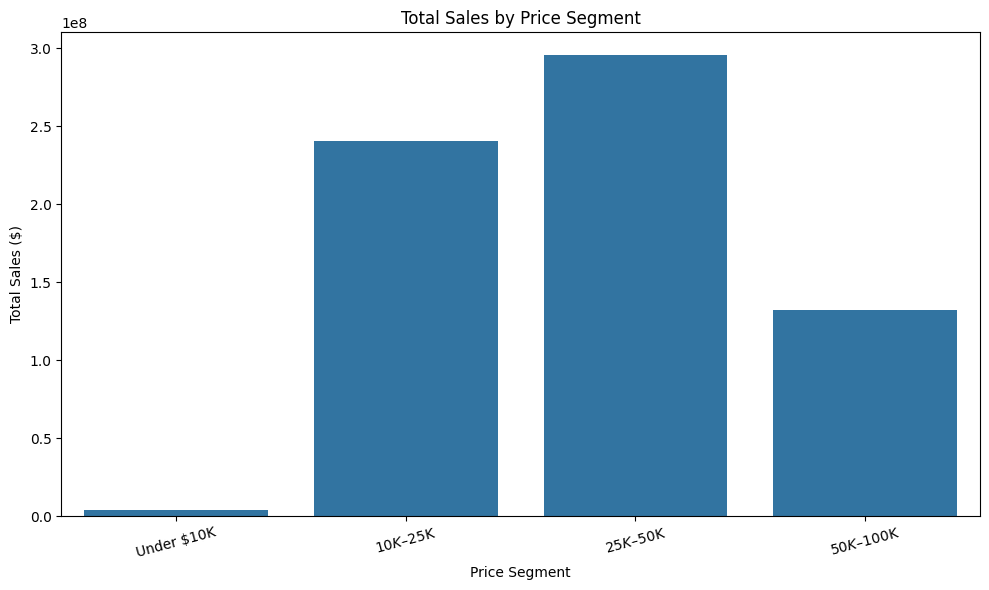

In [ ]:
plt.figure(figsize=(10, 6))

sns.barplot(data=price_segment_performance, x='Price_Segment', y='Total_Sales')

plt.title('Total Sales by Price Segment')
plt.xlabel('Price Segment')
plt.ylabel('Total Sales ($)')
plt.xticks(rotation=15)
plt.tight_layout()
plt.show()

### Pricing Interpretation


## Executive KPI Summary

In [ ]:
kpi_summary = pd.DataFrame({'Metric': ['Total Sales', 'Cars Sold', 'Average Selling Price',
        'Median Selling Price', 'Minimum Car Price', 'Maximum Car Price'],
    'Value': [
        df['Price_($)'].sum(),
        df['Car_id'].nunique(),
        df['Price_($)'].mean(),
        df['Price_($)'].median(),
        df['Price_($)'].min(),
        df['Price_($)'].max()
    ]
})

kpi_summary

,Metric,Value
0,Total Sales,6.715255e+08
1,Cars Sold,2.390600e+04
2,Average Selling Price,2.809025e+04
3,Median Selling Price,2.300000e+04
4,Minimum Car Price,1.200000e+03
5,Maximum Car Price,8.580000e+04


## Conclusion

The analysis demonstrates strong sales growth from 2022 to 2023, driven primarily by higher transaction volume rather than higher average selling prices.

Performance varies meaningfully across brands, models, regions, vehicle types, and price segments. Chevrolet is the leading brand by total sales, Austin is the strongest region, and the $25K–$50K segment is the largest revenue contributor.

The dataset supports clear descriptive and diagnostic sales analysis. However, profitability, customer lifetime value, inventory efficiency, and the causes of performance differences cannot be established from the available fields and would require additional business data.

# Export cleaned dataset for downstream analysis


In [ ]:
df.to_csv('car_sales_cleaned.csv', index=False)